# Loop vs Graph: one task, three builds

Companion notebook for the Nunnari Academy session **LOOP vs GRAPH: when a loop stops being enough** (Navaneeth Malingan, 19 Sep 2026).

> A loop and a graph are two different bets about how much you trust the model to decide what happens next. Most production failures are a system built as one when it needed to be the other.

We take one job, accounts payable (a vendor invoice goes from raw text to either a posted ledger entry or a ticket in the exception queue), and build it three ways with the same tools, the same model and the same instrumentation:

| Build | What it is | Who decides what happens next |
|---|---|---|
| **Loop** | `while True: model -> tools -> model` | The model, at runtime |
| **Graph** | Nodes, edges, a router, checkpoints (LangGraph) | You, up front. The model runs in one node. |
| **Hybrid** | The same graph plus one edge into a small bounded loop | You own the topology, the model owns judgment inside one node |

Then we push seven invoices through each build and watch where they split.

| Part | What happens |
|---|---|
| 1 | The task: reference data, five tools, seven invoices |
| 2 | Plumbing: the model interface and the trace (run it, skim it) |
| 3 | **The loop**, and four runs that show what it is good and bad at |
| 4 | **The graph**, one node per cell, and the same runs |
| 5 | **The hybrid**: one edge fixes the graph's worst failure |
| 6 | The bench: every invoice through every build |
| 7 | Self-checks: the claims of this notebook as assertions |
| 8 | The decision framework, and exercises |

**How to run it.** `Run All`. With `USE_MOCK = True` (second code cell) the notebook runs offline on a deterministic mock model: no API key, the same result every time. With `USE_MOCK = False` it calls Claude, and reads `ANTHROPIC_API_KEY` from the environment or from a `.env` file next to the notebook. No key found means it falls back to the mock and says so. Token counts are estimates under the mock and real numbers under Claude.

**Assumed knowledge.** You have called an LLM API and you know what tool use is.

**New to the idea?** Start with `loop_vs_graph_basics.ipynb`. It shows the same contrast on a much smaller task, with no model and no API key.

In [1]:
# Fresh environment (Colab, a new venv)? Uncomment and run once, then restart the kernel.
# %pip install -q "anthropic>=0.40" "langgraph>=1.0" "langchain-core>=1.0" "langgraph-checkpoint-sqlite>=2.0"
#
# If Part 4 fails with "module 'langchain' has no attribute 'debug'", your environment mixes
# langchain 1.x with an old langchain-core 0.3. The line above fixes it. A clean venv is better still:
#   python -m venv .venv && .venv/bin/pip install -r requirements.txt ipykernel     (then pick .venv as the kernel)

In [2]:
import json
import operator
import os
import re
import sqlite3
import time
import uuid
from dataclasses import dataclass, field
from typing import Annotated, Any, Literal, TypedDict

USE_MOCK = False    # False = call Claude. True = offline mock, same result every time. If the API dies mid-session: flip this, Run All.

# Read ANTHROPIC_API_KEY from a .env file next to the notebook, so the key is never typed on a shared screen.
if os.path.exists(".env"):
    for line in open(".env"):
        k, sep, v = line.strip().partition("=")
        if sep and not k.startswith("#"):
            os.environ.setdefault(k.strip(), v.strip().strip("'\""))

---
# Part 1. The task

Everything in this part is deliberately deterministic and in memory. The session is about control flow, not integrations, so the "systems" are dicts.

The task was picked because it carries every signal that pushes you from a loop toward a graph:

1. **Parallel work that converges.** Vendor, PO and duplicate lookups feed one decision.
2. **A human before the irreversible.** Anything at or above 2,00,000 INR needs a named approver before `post_to_ledger`.
3. **Recovery that differs by failure.** Unknown vendor, PO mismatch, duplicate and a transient 503 all need different exits.
4. **Shared state.** Extracted fields, lookups and validation results are read and written by several steps.

## 1.1 Reference data

Four vendors, four purchase orders, and two numbers that are business policy: the approval threshold and the PO tolerance. Keep an eye on where those two numbers get *used* in each build.

In [3]:
VENDORS = {
    "V-1001": {"vendor_id": "V-1001", "name": "Kovai Steel Traders", "gstin": "33AAACK1234F1Z5", "payment_terms": "NET30", "status": "active"},
    "V-1002": {"vendor_id": "V-1002", "name": "Sri Balaji Packaging", "gstin": "33AABCS5678G1Z2", "payment_terms": "NET15", "status": "active"},
    "V-1003": {"vendor_id": "V-1003", "name": "Nilgiri Logistics", "gstin": "33AADCN9012H1Z9", "payment_terms": "NET45", "status": "active"},
    "V-1004": {"vendor_id": "V-1004", "name": "Coimbatore Power Tools", "gstin": "33AAECC3456J1Z7", "payment_terms": "NET30", "status": "on_hold"},
}

PURCHASE_ORDERS = {
    "PO-7781": {"po_number": "PO-7781", "vendor_id": "V-1001", "amount": 118000.00, "currency": "INR", "status": "open", "description": "TMT bars 12mm, 20 MT"},
    "PO-7782": {"po_number": "PO-7782", "vendor_id": "V-1002", "amount": 42500.00, "currency": "INR", "status": "open", "description": "Corrugated boxes, 5000 units"},
    "PO-7790": {"po_number": "PO-7790", "vendor_id": "V-1003", "amount": 265000.00, "currency": "INR", "status": "open", "description": "Freight, Ooty to Chennai, Q3"},
    "PO-7795": {"po_number": "PO-7795", "vendor_id": "V-1001", "amount": 61000.00, "currency": "INR", "status": "closed", "description": "Binding wire"},
}

# Anything at or above this needs a human to approve before posting.
APPROVAL_THRESHOLD = 200000.00
# Tolerance between invoice amount and PO amount before it counts as a mismatch.
PO_TOLERANCE = 0.02

## 1.2 The world

`World` is the mutable state of the company for one run: the ledger, the exception queue, and the history of already posted invoices. Every run gets a fresh one, so runs never contaminate each other.

Three details matter later:

- `vendor_service_failures_remaining` is fault injection. Set it to 2 and `lookup_vendor` returns a 503 twice before it works.
- `trace` is where every tool call gets logged (the `Trace` class is in Part 2). The runners attach one per run.
- `ToolError` carries a machine-readable `kind` (`transient`, `not_found`). A model can read the message. A graph can *route* on the kind.

In [4]:
@dataclass
class World:
    """Mutable state of the 'company' for one run. Every run gets a fresh one."""
    ledger: list[dict] = field(default_factory=list)
    exceptions: list[dict] = field(default_factory=list)
    history: list[dict] = field(default_factory=list)     # invoices posted in earlier runs (seeded for the duplicate case)
    vendor_service_failures_remaining: int = 0            # fault injection: lookup_vendor fails this many times first
    vendor_service_calls: int = 0
    trace: Any = None                                     # the run's Trace (Part 2). Every tool call is logged on it.


class ToolError(Exception):
    """A tool failed. Carries a machine-readable kind so a graph can route on it."""

    def __init__(self, kind: str, message: str):
        super().__init__(message)
        self.kind = kind
        self.message = message

## 1.3 The five tools

The same five functions are exposed to the loop and to the graph. Extraction (reading the invoice) is done by the model, not by a tool.

First the two lookups. Notice the fault injection at the top of `lookup_vendor`.

In [5]:
def lookup_vendor(world: World, vendor_name: str) -> dict:
    """Find a vendor in the vendor master by (fuzzy) name."""
    world.vendor_service_calls += 1
    if world.vendor_service_failures_remaining > 0:                      # fault injection
        world.vendor_service_failures_remaining -= 1
        raise ToolError("transient", "vendor-service: 503 Service Unavailable (retry later)")
    key = vendor_name.strip().lower()
    for v in VENDORS.values():
        name = v["name"].lower()
        if key and (key in name or name in key):
            return dict(v)
    raise ToolError("not_found", f"vendor-service: no vendor matching '{vendor_name}'")


def lookup_po(world: World, po_number: str) -> dict:
    """Fetch a purchase order by number."""
    po = PURCHASE_ORDERS.get(po_number.strip().upper())
    if not po:
        raise ToolError("not_found", f"po-service: no purchase order '{po_number}'")
    return dict(po)

The duplicate check. Same vendor and invoice number, or same vendor and amount.

In [6]:
def check_duplicate(world: World, vendor_id: str, invoice_number: str, amount: float) -> dict:
    """Has this vendor already been paid for this invoice number, or for this exact amount?"""
    for h in world.history + world.ledger:
        if h["vendor_id"] != vendor_id:
            continue
        if h["invoice_number"].strip().upper() == invoice_number.strip().upper():
            return {"duplicate": True, "matched": h, "rule": "same vendor and invoice number"}
        if abs(h["amount"] - amount) < 0.01:
            return {"duplicate": True, "matched": h, "rule": "same vendor and amount"}
    return {"duplicate": False}

The two ways a run can end. `post_to_ledger` is **irreversible**: anything posted here gets paid. `escalate_to_human` puts a ticket in the exception queue with a reason code.

The whole session is about one question: *what stands between an invoice and `post_to_ledger`?*

In [7]:
def post_to_ledger(world: World, vendor_id: str, invoice_number: str, amount: float, approved_by: str, po_number: str | None = None) -> dict:
    """Post the invoice to the ledger. IRREVERSIBLE. Anything posted here gets paid."""
    entry = {"ledger_id": f"LDG-{len(world.ledger) + len(world.history) + 1:05d}", "vendor_id": vendor_id,
             "invoice_number": invoice_number, "amount": amount, "po_number": po_number, "approved_by": approved_by}
    world.ledger.append(entry)
    return entry


def escalate_to_human(world: World, reason: str, summary: str) -> dict:
    """Put the invoice in the exception queue for an AP analyst. Ends processing for now."""
    item = {"ticket_id": f"EXC-{len(world.exceptions) + 1:04d}", "reason": reason, "summary": summary}
    world.exceptions.append(item)
    return item

## 1.4 Tool schemas and the dispatcher

`TOOL_SCHEMAS` is what the model sees: a name, a description and a JSON schema per tool.

Two ways to call a tool, and the difference is the whole session in miniature:

- **`call_tool`** logs the call on the trace and lets a `ToolError` **raise**. The graph uses it, because code can catch an error and route on its `kind`.
- **`run_tool`** wraps it and **never raises**. Errors come back as `{"error": ..., "kind": ...}`, because the only thing a loop can do with an error is show it to the model.

In [8]:
# Anthropic tool-use schemas. Same list for both agents.
TOOL_SCHEMAS: list[dict] = [
    {
        "name": "lookup_vendor",
        "description": "Find a vendor in the vendor master by name. Returns vendor_id, GSTIN, payment terms and status. Raises not_found or transient errors.",
        "input_schema": {"type": "object", "properties": {"vendor_name": {"type": "string"}}, "required": ["vendor_name"]},
    },
    {
        "name": "lookup_po",
        "description": "Fetch a purchase order by PO number. Returns vendor_id, amount, currency and status.",
        "input_schema": {"type": "object", "properties": {"po_number": {"type": "string"}}, "required": ["po_number"]},
    },
    {
        "name": "check_duplicate",
        "description": "Check whether an invoice from this vendor with this number or amount has already been posted.",
        "input_schema": {
            "type": "object",
            "properties": {"vendor_id": {"type": "string"}, "invoice_number": {"type": "string"}, "amount": {"type": "number"}},
            "required": ["vendor_id", "invoice_number", "amount"],
        },
    },
    {
        "name": "post_to_ledger",
        "description": "Post the invoice to the ledger so it gets paid. IRREVERSIBLE. Only call after the vendor is verified, the PO matches, and the duplicate check is clean. approved_by is 'auto' below the approval threshold, otherwise the name of the human who approved.",
        "input_schema": {
            "type": "object",
            "properties": {
                "vendor_id": {"type": "string"},
                "invoice_number": {"type": "string"},
                "amount": {"type": "number"},
                "po_number": {"type": ["string", "null"]},
                "approved_by": {"type": "string"},
            },
            "required": ["vendor_id", "invoice_number", "amount", "approved_by"],
        },
    },
    {
        "name": "escalate_to_human",
        "description": "Send the invoice to the AP exception queue with a reason code (unknown_vendor, po_mismatch, duplicate, needs_approval, unreadable, other) and a one-paragraph summary. Ends processing.",
        "input_schema": {
            "type": "object",
            "properties": {"reason": {"type": "string"}, "summary": {"type": "string"}},
            "required": ["reason", "summary"],
        },
    },
]


TOOLS = {fn.__name__: fn for fn in (lookup_vendor, lookup_po, check_duplicate, post_to_ledger, escalate_to_human)}


def call_tool(world: World, name: str, **args) -> dict:
    """Run one tool and log it on the trace. A ToolError still raises. The graph uses this."""
    try:
        result = TOOLS[name](world, **args)
    except ToolError as e:
        if world.trace:
            world.trace.tool(name, args, {"error": e.message, "kind": e.kind})
        raise
    if world.trace:
        world.trace.tool(name, args, result)
    return result


def run_tool(world: World, name: str, args: dict) -> dict:
    """The loop uses this. It never raises: errors go back to the model as data."""
    try:
        return call_tool(world, name, **args)
    except ToolError as e:
        return {"error": e.message, "kind": e.kind}
    except (KeyError, TypeError) as e:
        return {"error": f"bad call to {name}: {e}", "kind": "bad_call"}

## 1.5 Try the tools by hand

Before any agent touches them. A good lookup, a PO, a vendor that does not exist, and the flaky service.

In [9]:
w = World()
print(lookup_vendor(w, "kovai steel traders"))
print(lookup_po(w, "PO-7781"))

try:
    lookup_vendor(w, "Western Ghats Hardware Mart")
except ToolError as e:
    print(f"ToolError kind={e.kind!r}  message={e.message!r}")

{'vendor_id': 'V-1001', 'name': 'Kovai Steel Traders', 'gstin': '33AAACK1234F1Z5', 'payment_terms': 'NET30', 'status': 'active'}
{'po_number': 'PO-7781', 'vendor_id': 'V-1001', 'amount': 118000.0, 'currency': 'INR', 'status': 'open', 'description': 'TMT bars 12mm, 20 MT'}
ToolError kind='not_found'  message="vendor-service: no vendor matching 'Western Ghats Hardware Mart'"


In [10]:
# Fault injection: two 503s, then success. Remember this one for scenario S5.
flaky = World(vendor_service_failures_remaining=2)
for attempt in (1, 2, 3):
    print(attempt, run_tool(flaky, "lookup_vendor", {"vendor_name": "Kovai Steel Traders"}))

1 {'error': 'vendor-service: 503 Service Unavailable (retry later)', 'kind': 'transient'}
2 {'error': 'vendor-service: 503 Service Unavailable (retry later)', 'kind': 'transient'}
3 {'vendor_id': 'V-1001', 'name': 'Kovai Steel Traders', 'gstin': '33AAACK1234F1Z5', 'payment_terms': 'NET30', 'status': 'active'}


## 1.6 Seven invoices

Each invoice is chosen to press on one architectural question. The text is intentionally messy, the way scanned and OCR'd invoices are.

| | Invoice | What it presses on |
|---|---|---|
| S1 | Clean, under threshold | Baseline. Compare model calls and tokens for the same outcome. |
| S2 | Duplicate of a posted invoice | Is "check before post" a guarantee or a request in a prompt? |
| S3 | Unknown vendor | A failure with an obvious recovery path. |
| S4 | 9% over the PO, tolerance 2% | Where does a business rule live, and can you test it? |
| S5 | Vendor service 503s twice | What does a retry cost, in calls and tokens? |
| S6 | A credit note, not an invoice | The branch nobody drew. |
| S7 | 2,65,000 INR, above threshold | A human has to say yes, and is not online right now. |

In [11]:
@dataclass
class Scenario:
    key: str
    title: str
    invoice_text: str
    why: str
    expected: str                        # "posted" | "escalated" | "paused"
    expected_reason: str | None = None
    setup: dict = field(default_factory=dict)

    def make_world(self) -> World:
        return World(history=list(self.setup.get("history", [])),
                     vendor_service_failures_remaining=self.setup.get("vendor_failures", 0))

In [12]:
SCENARIOS = {s.key: s for s in [

Scenario(
    key="S1", title="Clean invoice",
    expected="posted", expected_reason="auto",
    why="The baseline. Both architectures should sail through. Compare turns and tokens.",
    invoice_text="""
TAX INVOICE
Kovai Steel Traders
No. 14, Avinashi Road, Coimbatore 641018   GSTIN 33AAACK1234F1Z5

Invoice No: KST/2026/0912          Date: 12-Sep-2026
Your PO Ref: PO-7781
Bill to: Nunnari Labs Pvt Ltd

Description                          Qty      Rate        Amount
TMT bars 12mm Fe500                  20 MT    5,000.00    1,00,000.00
                                              CGST 9%        9,000.00
                                              SGST 9%        9,000.00
                                              TOTAL      1,18,000.00
Amount in words: One lakh eighteen thousand only
""",
),

Scenario(
    key="S2", title="Duplicate invoice",
    expected="escalated", expected_reason="duplicate",
    why="Same invoice, sent again. The question is not whether the agent CAN catch it, it is whether anything guarantees the check runs before post_to_ledger.",
    setup={"history": [
        {"ledger_id": "LDG-00017", "vendor_id": "V-1002", "invoice_number": "SBP-4471", "amount": 42500.00, "po_number": "PO-7782", "approved_by": "auto"},
    ]},
    invoice_text="""
Sri Balaji Packaging          GSTIN 33AABCS5678G1Z2
INVOICE # SBP-4471            Dated 03/09/2026     PO: PO-7782
To: Nunnari Labs Private Limited, Periyanaickenpalayam

Corrugated boxes 5-ply 18x12x10, 5000 nos @ Rs 7.20     36,000.00
GST 18%                                                   6,500.00
Grand Total                                              42,500.00

** REMINDER: this invoice is overdue. Kindly release payment. **
""",
),

Scenario(
    key="S3", title="Unknown vendor",
    expected="escalated", expected_reason="unknown_vendor",
    why="A recoverable failure with an obvious recovery path. Both should escalate. Watch how each one gets there.",
    invoice_text="""
BILL
Western Ghats Hardware Mart
Ooty Main Road, Mettupalayam

Bill No 118  Date 10.09.2026
Supply of anchor bolts M16 x 150, 400 pcs @ 62      24,800.00
GST 18%                                              4,464.00
Total                                               29,264.00
PO: PO-7781
""",
),

Scenario(
    key="S4", title="PO amount mismatch",
    expected="escalated", expected_reason="po_mismatch",
    why="Invoice is 9% over the PO. Tolerance is 2%. A rule, not a judgment call. Where does the rule live in each version?",
    invoice_text="""
TAX INVOICE   Nilgiri Logistics   GSTIN 33AADCN9012H1Z9
Inv No NL-Q3-0088     Date 15 Sep 2026     PO PO-7790
Freight charges, Ooty to Chennai, July-Sept 2026
Base freight                                        2,45,000.00
Fuel surcharge (revised, see attached notice)          9,200.00
GST 18%                                               45,756.00
TOTAL PAYABLE                                       2,89,956.00
""",
),

Scenario(
    key="S5", title="Flaky vendor service",
    expected="posted", expected_reason="auto",
    why="lookup_vendor returns 503 twice before succeeding. The loop pays tokens to decide to retry. The graph retries in a policy with zero tokens.",
    setup={"vendor_failures": 2},
    invoice_text="""
Kovai Steel Traders   GSTIN 33AAACK1234F1Z5
Invoice No KST/2026/0931   Date 14-Sep-2026   PO Ref PO-7781
TMT bars 12mm Fe500, 20 MT @ 5,000       1,00,000.00
CGST 9% + SGST 9%                          18,000.00
TOTAL                                    1,18,000.00
""",
),

Scenario(
    key="S6", title="Credit note (the branch nobody drew)",
    expected="escalated", expected_reason="other",
    why="Not an invoice at all. The loop reads it and copes. The graph does whatever its router does with a document type it was never told about.",
    invoice_text="""
CREDIT NOTE
Sri Balaji Packaging   GSTIN 33AABCS5678G1Z2
Credit Note No: SBP-CN-0093     Date 16/09/2026
Against our Invoice SBP-4471 dated 03/09/2026
Reason: 500 boxes returned damaged
Credit amount                                   -4,250.00
GST reversal 18%                                  -765.00
TOTAL CREDIT                                    -5,015.00
Please adjust against next payment.
""",
),

Scenario(
    key="S7", title="Big ticket, needs approval",
    expected="paused", expected_reason="needs_approval",
    why="Above the approval threshold. Somebody has to say yes before the money moves, and that somebody is not online right now.",
    invoice_text="""
TAX INVOICE   Nilgiri Logistics   GSTIN 33AADCN9012H1Z9
Inv No NL-Q3-0091     Date 16 Sep 2026     PO PO-7790
Freight charges, Ooty to Chennai, July-Sept 2026 (as per PO)
Base freight                                        2,24,576.27
GST 18%                                               40,423.73
TOTAL PAYABLE                                       2,65,000.00
""",
),

]}

ORDER = ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]

In [13]:
for k in ORDER:
    s = SCENARIOS[k]
    print(f"{k}  {s.title:<38} expected: {s.expected:<9} {s.expected_reason or ''}")
    print(f"    {s.why}")

S1  Clean invoice                          expected: posted    auto
    The baseline. Both architectures should sail through. Compare turns and tokens.
S2  Duplicate invoice                      expected: escalated duplicate
    Same invoice, sent again. The question is not whether the agent CAN catch it, it is whether anything guarantees the check runs before post_to_ledger.
S3  Unknown vendor                         expected: escalated unknown_vendor
    A recoverable failure with an obvious recovery path. Both should escalate. Watch how each one gets there.
S4  PO amount mismatch                     expected: escalated po_mismatch
    Invoice is 9% over the PO. Tolerance is 2%. A rule, not a judgment call. Where does the rule live in each version?
S5  Flaky vendor service                   expected: posted    auto
    lookup_vendor returns 503 twice before succeeding. The loop pays tokens to decide to retry. The graph retries in a policy with zero tokens.
S6  Credit note (the branch

Read two of them the way the agent will: as raw text. S1 is the clean one. S6 is the one that causes trouble later.

In [14]:
print(SCENARIOS["S1"].invoice_text)
print("-" * 70)
print(SCENARIOS["S6"].invoice_text)


TAX INVOICE
Kovai Steel Traders
No. 14, Avinashi Road, Coimbatore 641018   GSTIN 33AAACK1234F1Z5

Invoice No: KST/2026/0912          Date: 12-Sep-2026
Your PO Ref: PO-7781
Bill to: Nunnari Labs Pvt Ltd

Description                          Qty      Rate        Amount
TMT bars 12mm Fe500                  20 MT    5,000.00    1,00,000.00
                                              CGST 9%        9,000.00
                                              SGST 9%        9,000.00
                                              TOTAL      1,18,000.00
Amount in words: One lakh eighteen thousand only

----------------------------------------------------------------------

CREDIT NOTE
Sri Balaji Packaging   GSTIN 33AABCS5678G1Z2
Credit Note No: SBP-CN-0093     Date 16/09/2026
Against our Invoice SBP-4471 dated 03/09/2026
Reason: 500 boxes returned damaged
Credit amount                                   -4,250.00
GST reversal 18%                                  -765.00
TOTAL CREDIT                

---
# Part 2. Plumbing: the model and the trace

Run these cells. Skim them. None of the argument lives here.

## 2.1 One model interface

Every build talks to the model only through `model.complete(system, messages, tools)`, which returns a `ModelReply`. Swapping the implementation never changes control flow, which is what makes the comparison fair.

The two helpers at the bottom are the two halves of a turn: `as_assistant_message()` puts the model's reply on the transcript, `tool_results()` puts the observations after it.

In [15]:
DEFAULT_MODEL = os.environ.get("ANTHROPIC_MODEL", "claude-sonnet-5")


@dataclass
class ToolCall:
    id: str
    name: str
    args: dict


@dataclass
class ModelReply:
    text: str
    tool_calls: list[ToolCall]
    stop_reason: str
    input_tokens: int
    output_tokens: int

    def as_assistant_message(self) -> dict:
        """The reply, as the next message on the transcript."""
        blocks = [{"type": "text", "text": self.text}] if self.text else []
        blocks += [{"type": "tool_use", "id": tc.id, "name": tc.name, "input": tc.args} for tc in self.tool_calls]
        return {"role": "assistant", "content": blocks}


def tool_results(reply: ModelReply, results: list[dict]) -> dict:
    """The observation: one tool_result per tool call, sent back as the next user message."""
    return {"role": "user", "content": [{"type": "tool_result", "tool_use_id": tc.id, "content": json.dumps(r)}
                                        for tc, r in zip(reply.tool_calls, results)]}

## 2.2 The real model

Claude tool use through the Anthropic SDK. The SDK is imported lazily so the mock path has no dependency on it.

In [16]:
class AnthropicModel:
    def __init__(self, model: str = DEFAULT_MODEL):
        import anthropic  # imported lazily so the mock path has no SDK dependency

        self.client = anthropic.Anthropic()
        self.name = model

    def complete(self, system, messages, tools=None, max_tokens=1024) -> ModelReply:
        kwargs = {"tools": tools} if tools else {}
        resp = self.client.messages.create(model=self.name, system=system, messages=messages, max_tokens=max_tokens, **kwargs)
        return ModelReply(
            text="\n".join(b.text for b in resp.content if b.type == "text").strip(),
            tool_calls=[ToolCall(b.id, b.name, dict(b.input)) for b in resp.content if b.type == "tool_use"],
            stop_reason=resp.stop_reason or "",
            input_tokens=resp.usage.input_tokens,
            output_tokens=resp.usage.output_tokens,
        )

## 2.3 The mock model

A deterministic stand-in so the notebook runs offline and gives the same answer every time. Its "reasoning" is a rule table that behaves like a competent, slightly literal agent following the system prompt. It has two jobs: with no tools it extracts fields (regex), with tools it picks the next tool call from the transcript so far.

This is the longest cell in the notebook and the least important. **Do not read it in a session.** The one thing worth knowing: on a transient error it retries up to three times, then gives up, like a sensible model would.

In [17]:
_MONEY = r"(-?)\s*(?:Rs\.?|INR|₹)?\s*([0-9][0-9,]*\.?[0-9]*)"


def extract_fields(text: str) -> dict:
    """Regex 'extraction'. Good enough for the fixtures; the real model does this properly."""
    t = text
    doc_type = "credit_note" if re.search(r"CREDIT\s+NOTE", t, re.I) else "invoice"
    # vendor: first non-empty line that is not a document heading
    t = re.sub(r"^\s*Process this invoice:\s*", "", t)
    vendor = None
    for line in t.strip().splitlines():
        s = re.sub(r"^(TAX\s+INVOICE|INVOICE|BILL|CREDIT\s+NOTE)\b[\s:]*", "", line.strip(), flags=re.I)
        if not s:
            continue
        vendor = re.split(r"\s{2,}|GSTIN", s)[0].strip()
        break
    m = re.search(r"(?:Invoice\s*(?:No|#|Number)\.?|Inv\s*No\.?|Bill\s*No\.?|Credit\s+Note\s+No\.?)\s*[:#]?\s*([A-Z0-9][A-Z0-9/\-]*)", t, re.I)
    invoice_number = m.group(1) if m else None
    m = re.search(r"\b(PO-\d{3,})\b", t, re.I)
    po_number = m.group(1).upper() if m else None
    m = re.search(r"(?:TOTAL(?:\s+PAYABLE|\s+CREDIT)?|Grand\s+Total|Total)\s*:?\s*" + _MONEY, t, re.I)
    amount = None
    if m:
        sign = -1 if m.group(1) == "-" else 1
        amount = sign * float(m.group(2).replace(",", ""))
    m = re.search(r"GSTIN\s*:?\s*([0-9A-Z]{15})", t)
    gstin = m.group(1) if m else None
    m = re.search(r"Date[d]?\s*:?\s*([0-9]{1,2}[-/. ][A-Za-z0-9]{2,3}[-/. ][0-9]{2,4})", t, re.I)
    date = m.group(1) if m else None
    return {
        "document_type": doc_type,
        "vendor_name": vendor,
        "gstin": gstin,
        "invoice_number": invoice_number,
        "invoice_date": date,
        "po_number": po_number,
        "amount": amount,
        "currency": "INR",
        "confidence": 0.93 if all([vendor, invoice_number, amount]) else 0.55,
    }


def _flatten_text(content) -> str:
    if isinstance(content, str):
        return content
    out = []
    for b in content:
        if b.get("type") == "text":
            out.append(b["text"])
        elif b.get("type") == "tool_result":
            c = b.get("content")
            out.append(c if isinstance(c, str) else json.dumps(c))
        elif b.get("type") == "tool_use":
            out.append(json.dumps(b.get("input", {})))
    return "\n".join(out)


def _estimate_tokens(*chunks: str) -> int:
    return max(1, sum(len(c) for c in chunks) // 4)

In [18]:
class MockModel:
    """
    Behaves like a careful agent following the system prompt literally:
    look up vendor and PO together, then check duplicates, then post or escalate.
    On a transient error it retries up to `max_retries` times, then gives up.
    """

    name = "mock"

    def __init__(self, max_retries: int = 3):
        self.max_retries = max_retries

    # -- helpers -----------------------------------------------------------
    @staticmethod
    def _tool_history(messages: list[dict]) -> list[tuple[str, dict, dict]]:
        """[(tool_name, args, result), ...] in order, reconstructed from the transcript."""
        pending: dict[str, tuple[str, dict]] = {}
        hist: list[tuple[str, dict, dict]] = []
        for m in messages:
            if isinstance(m["content"], str):
                continue
            for b in m["content"]:
                if b.get("type") == "tool_use":
                    pending[b["id"]] = (b["name"], b["input"])
                elif b.get("type") == "tool_result":
                    name, args = pending.get(b["tool_use_id"], ("?", {}))
                    c = b.get("content")
                    try:
                        res = json.loads(c) if isinstance(c, str) else c
                    except json.JSONDecodeError:
                        res = {"raw": c}
                    hist.append((name, args, res))
        return hist

    def _reply(self, messages, system, text="", calls=None) -> ModelReply:
        calls = calls or []
        inp = _estimate_tokens(system, *[_flatten_text(m["content"]) for m in messages])
        out = _estimate_tokens(text, *[json.dumps(c.args) for c in calls])
        return ModelReply(text=text, tool_calls=calls, stop_reason="tool_use" if calls else "end_turn",
                          input_tokens=inp, output_tokens=out)

    @staticmethod
    def _call(name, **args) -> ToolCall:
        return ToolCall(id=f"toolu_{uuid.uuid4().hex[:12]}", name=name, args=args)

    # -- the two jobs ------------------------------------------------------
    def complete(self, system, messages, tools=None, max_tokens=1024) -> ModelReply:
        if not tools:
            return self._extract(system, messages)
        return self._act(system, messages)

    def _extract(self, system, messages) -> ModelReply:
        text = _flatten_text(messages[-1]["content"])
        fields = extract_fields(text)
        return self._reply(messages, system, text=json.dumps(fields))

    def _act(self, system, messages) -> ModelReply:
        first_user = _flatten_text(messages[0]["content"])
        f = extract_fields(first_user)
        hist = self._tool_history(messages)
        by_name = {}
        for name, args, res in hist:
            by_name.setdefault(name, []).append((args, res))

        def esc(reason, summary):
            return self._reply(messages, system, text=f"Escalating: {reason}.", calls=[self._call("escalate_to_human", reason=reason, summary=summary)])

        # Terminal: something already ended the job.
        if "escalate_to_human" in by_name:
            return self._reply(messages, system, text="Invoice escalated to the AP exception queue. Done.")
        if "post_to_ledger" in by_name:
            entry = by_name["post_to_ledger"][-1][1]
            return self._reply(messages, system, text=f"Posted as {entry.get('ledger_id')}. Done.")

        if f["document_type"] == "credit_note":
            return esc("other", f"Document is a credit note ({f['invoice_number']}) against a prior invoice, not a payable invoice. Needs manual adjustment against the vendor balance.")
        if f["confidence"] < 0.6:
            return esc("unreadable", "Could not reliably extract vendor, invoice number and amount.")

        # Step 1: vendor and PO lookups (issued together, like a model doing parallel tool use).
        vendor_ok = next((r for a, r in by_name.get("lookup_vendor", []) if "error" not in r), None)
        vendor_attempts = by_name.get("lookup_vendor", [])
        po_calls = by_name.get("lookup_po", [])
        if vendor_ok is None:
            if vendor_attempts:
                last = vendor_attempts[-1][1]
                if last.get("kind") == "not_found":
                    return esc("unknown_vendor", f"No vendor master record for '{f['vendor_name']}' (GSTIN {f['gstin'] or 'not printed'}). Needs vendor onboarding before this can be paid.")
                if last.get("kind") == "transient":
                    if len(vendor_attempts) >= self.max_retries:
                        return esc("other", f"Vendor service unavailable after {len(vendor_attempts)} attempts. Please retry later.")
                    return self._reply(messages, system, text="Vendor service returned a transient error. Retrying.",
                                       calls=[self._call("lookup_vendor", vendor_name=f["vendor_name"])])
            calls = [self._call("lookup_vendor", vendor_name=f["vendor_name"])]
            if f["po_number"] and not po_calls:
                calls.append(self._call("lookup_po", po_number=f["po_number"]))
            return self._reply(messages, system, text="Looking up the vendor and the PO.", calls=calls)

        # Step 2: PO validation.
        if f["po_number"] and not po_calls:
            return self._reply(messages, system, text="Fetching the PO.", calls=[self._call("lookup_po", po_number=f["po_number"])])
        if f["po_number"]:
            po = po_calls[-1][1]
            if "error" in po:
                return esc("po_mismatch", f"PO {f['po_number']} not found.")
            if po.get("vendor_id") != vendor_ok["vendor_id"]:
                return esc("po_mismatch", f"PO {f['po_number']} belongs to {po.get('vendor_id')}, invoice is from {vendor_ok['vendor_id']}.")
            if abs(f["amount"] - po["amount"]) > PO_TOLERANCE * po["amount"]:
                return esc("po_mismatch", f"Invoice {f['amount']:.2f} vs PO {po['amount']:.2f} ({(f['amount'] / po['amount'] - 1) * 100:+.1f}%), outside the 2% tolerance.")

        # Step 3: duplicate check.
        dups = by_name.get("check_duplicate", [])
        if not dups:
            return self._reply(messages, system, text="Checking for duplicates.",
                               calls=[self._call("check_duplicate", vendor_id=vendor_ok["vendor_id"], invoice_number=f["invoice_number"], amount=f["amount"])])
        if dups[-1][1].get("duplicate"):
            return esc("duplicate", f"Invoice {f['invoice_number']} already posted as {dups[-1][1]['matched'].get('ledger_id')} ({dups[-1][1]['rule']}).")

        # Step 4: approval and posting.
        if f["amount"] >= APPROVAL_THRESHOLD:
            return esc("needs_approval", f"Amount {f['amount']:.2f} is above the {APPROVAL_THRESHOLD:.0f} approval threshold. Needs a human approver; I cannot wait for one.")
        return self._reply(messages, system, text="All checks passed. Posting.",
                           calls=[self._call("post_to_ledger", vendor_id=vendor_ok["vendor_id"], invoice_number=f["invoice_number"],
                                             amount=f["amount"], po_number=f["po_number"], approved_by="auto")])

In [19]:
def make_model(mock: bool):
    if not mock and not os.environ.get("ANTHROPIC_API_KEY"):
        print("ANTHROPIC_API_KEY not found (environment or .env), falling back to the mock model")
        mock = True
    return MockModel() if mock else AnthropicModel()


model = make_model(mock=USE_MOCK)
print("model:", model.name)

model: claude-sonnet-5


## 2.4 The trace

Instrumentation shared by all three builds, so the comparison is apples to apples. It counts model calls, input and output tokens, tool calls and wall time, and keeps a flat event log that `print_report()` prints.

In [20]:
@dataclass
class Trace:
    agent: str
    scenario: str
    model_calls: int = 0
    input_tokens: int = 0
    output_tokens: int = 0
    events: list[str] = field(default_factory=list)
    started: float = field(default_factory=time.time)
    seconds: float = 0.0
    outcome: str = "unknown"          # posted | escalated | paused | failed | max_turns
    detail: str = ""

    def model(self, where: str, reply: ModelReply) -> None:
        self.model_calls += 1
        self.input_tokens += reply.input_tokens
        self.output_tokens += reply.output_tokens
        said = " ".join(reply.text.split())[:80] or "(no text) asks for: " + ", ".join(tc.name for tc in reply.tool_calls)
        self.events.append(f"model   {where:<18} in={reply.input_tokens:<5} out={reply.output_tokens:<4} {said}")

    def tool(self, name: str, args: dict, result: dict) -> None:
        self.events.append(f"tool    {name:<18} {json.dumps(args)[:70]:<70} -> {json.dumps(result)[:80]}")

    def note(self, where: str, text: str) -> None:
        self.events.append(f"note    {where:<18} {text}")

    @property
    def tool_calls(self) -> int:
        return sum(e.startswith("tool") for e in self.events)

    def end(self, outcome: str, detail: str = "") -> "Trace":
        self.seconds = round(time.time() - self.started, 2)
        self.outcome, self.detail = outcome, detail
        return self

    def print_report(self, verbose: bool = True) -> None:
        print(f"\n== {self.agent.upper()}  {self.scenario}  ->  {self.outcome}  ({self.detail})")
        if verbose:
            for e in self.events:
                print("  " + e)
        print(f"  model calls={self.model_calls}  tokens in/out={self.input_tokens}/{self.output_tokens}  tool calls={self.tool_calls}  wall={self.seconds}s")


def finish(trace: Trace, world: World, otherwise=("failed", "ended without posting or escalating")) -> Trace:
    """What actually happened? Read it off the world, not off what the model said."""
    if world.ledger:
        return trace.end("posted", f"{world.ledger[-1]['ledger_id']} approved_by={world.ledger[-1]['approved_by']}")
    if world.exceptions:
        return trace.end("escalated", world.exceptions[-1]["reason"])
    return trace.end(*otherwise)

---
# Part 3. The loop

```
while True:
    reply = model(messages, tools)
    if no tool calls: break
    run the tools, append results, continue
```

Structure is **deferred to runtime**. The model reads the invoice, decides which tool to call, reads the result, decides again. The only things the code decides are the tool surface, the system prompt and the turn budget.

## 3.1 The system prompt

Read the rules. This prompt *is* the control flow. Pay attention to rule 4.

In [21]:
SYSTEM_PROMPT = f"""You are an accounts-payable agent for Nunnari Labs. You receive one vendor invoice as raw text and must get it either posted to the ledger or escalated to a human, safely.

Rules:
1. Read the invoice and identify vendor name, invoice number, PO number (if any), and total amount.
2. Verify the vendor exists in the vendor master (lookup_vendor). Unknown vendor: escalate with reason unknown_vendor.
3. If a PO is referenced, fetch it (lookup_po). The PO must belong to the same vendor and the invoice total must be within 2% of the PO amount. Otherwise escalate with reason po_mismatch.
4. ALWAYS run check_duplicate before posting. If it is a duplicate, escalate with reason duplicate. Never post a duplicate.
5. Invoices of {APPROVAL_THRESHOLD:,.0f} INR or more need a named human approver before posting. You cannot obtain approval yourself, so escalate with reason needs_approval.
6. If the document is not a payable invoice (credit note, statement, quotation), escalate with reason other and explain.
7. If a tool fails with a transient error you may retry it. Do not retry more than a few times.
8. post_to_ledger is irreversible. Only call it once, only after every check above has passed, with approved_by="auto".

Be brief. Call tools rather than describing what you would do. When the job is finished (posted or escalated), reply with one sentence and stop."""

print(SYSTEM_PROMPT)

You are an accounts-payable agent for Nunnari Labs. You receive one vendor invoice as raw text and must get it either posted to the ledger or escalated to a human, safely.

Rules:
1. Read the invoice and identify vendor name, invoice number, PO number (if any), and total amount.
2. Verify the vendor exists in the vendor master (lookup_vendor). Unknown vendor: escalate with reason unknown_vendor.
3. If a PO is referenced, fetch it (lookup_po). The PO must belong to the same vendor and the invoice total must be within 2% of the PO amount. Otherwise escalate with reason po_mismatch.
4. ALWAYS run check_duplicate before posting. If it is a duplicate, escalate with reason duplicate. Never post a duplicate.
5. Invoices of 200,000 INR or more need a named human approver before posting. You cannot obtain approval yourself, so escalate with reason needs_approval.
6. If the document is not a payable invoice (credit note, statement, quotation), escalate with reason other and explain.
7. If a tool

## 3.2 One turn, by hand

Before the loop, a single turn. Send the invoice and the tool list, look at what comes back: a little text and a list of tool calls. The model has not *done* anything. It has asked us to.

In [22]:
messages = [{"role": "user", "content": f"Process this invoice:\n\n{SCENARIOS['S1'].invoice_text.strip()}"}]
reply = model.complete(SYSTEM_PROMPT, messages, tools=TOOL_SCHEMAS)

print("text:       ", reply.text)
for tc in reply.tool_calls:
    print("tool call:  ", tc.name, tc.args)
print("stop_reason:", reply.stop_reason, f"  tokens in/out: {reply.input_tokens}/{reply.output_tokens}")

text:        
tool call:   lookup_vendor {'vendor_name': 'Kovai Steel Traders'}
tool call:   lookup_po {'po_number': 'PO-7781'}
stop_reason: tool_use   tokens in/out: 1838/138


## 3.3 The loop itself

Run the tools the model asked for, append the results, call the model again. Repeat until the model stops asking. That is the whole agent, and it is the same code as the *ReAct in twelve lines* slide: thought and action are the model call, observation is `tool_results`.

Read it once and notice what is **not** here:

- no ordering guarantee between `check_duplicate` and `post_to_ledger`
- no way to pause for a human and come back tomorrow
- no retry policy that does not cost tokens

Every one of those lives in the system prompt, which is to say it lives in the model's judgment.

In [23]:
MAX_TURNS = 12


def run_loop(model, world: World, invoice_text: str, scenario_key: str, max_turns: int = MAX_TURNS) -> Trace:
    trace = world.trace = Trace("loop", scenario_key)
    messages = [{"role": "user", "content": f"Process this invoice:\n\n{invoice_text.strip()}"}]

    for turn in range(1, max_turns + 1):                                          # the budget
        reply = model.complete(SYSTEM_PROMPT, messages, tools=TOOL_SCHEMAS)       # thought + action
        trace.model(f"turn {turn}", reply)
        messages.append(reply.as_assistant_message())
        if not reply.tool_calls:
            return finish(trace, world)                                           # the model says it is done. who checked?
        results = [run_tool(world, tc.name, tc.args) for tc in reply.tool_calls]
        messages.append(tool_results(reply, results))                             # observation

    # Out of turns: the loop's only structural safety net.
    return finish(trace, world, otherwise=("max_turns", f"no outcome after {max_turns} turns"))

A small runner used for the rest of the notebook. It makes a fresh `World` for the scenario, runs the chosen build and prints the trace. (`run_graph` does not exist yet. Python looks it up when called, so that is fine until Part 4.)

In [24]:
def run_one(agent: str, key: str, verbose: bool = True, report: bool = True, thread_id: str | None = None, persist_path: str | None = None):
    sc = SCENARIOS[key]
    world = sc.make_world()
    if agent == "loop":
        tr = run_loop(model, world, sc.invoice_text, key)
    else:
        tr = run_graph(model, world, sc.invoice_text, key, variant=agent, thread_id=thread_id, persist_path=persist_path)
    if report:
        tr.print_report(verbose=verbose)
    return tr, world

## 3.4 Run 1: the loop works

The clean invoice first. Count the model calls.

In [25]:
tr, world = run_one("loop", "S1")
world.ledger


== LOOP  S1  ->  posted  (LDG-00001 approved_by=auto)
  model   turn 1             in=1838  out=135  (no text) asks for: lookup_vendor, lookup_po
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"vendor_id": "V-1001", "name": "Kovai Steel Traders", "gstin": "33AAACK1234F1Z5
  tool    lookup_po          {"po_number": "PO-7781"}                                               -> {"po_number": "PO-7781", "vendor_id": "V-1001", "amount": 118000.0, "currency": 
  model   turn 2             in=2154  out=139  PO matches vendor and amount exactly. Now checking for duplicates.
  tool    check_duplicate    {"vendor_id": "V-1001", "invoice_number": "KST/2026/0912", "amount": 1 -> {"duplicate": false}
  model   turn 3             in=2307  out=199  Not a duplicate and amount is below the 200,000 INR approval threshold, so posti
  tool    post_to_ledger     {"vendor_id": "V-1001", "invoice_number": "KST/2026/0912", "amount": 1 -> {"ledger_id": "L

[{'ledger_id': 'LDG-00001',
  'vendor_id': 'V-1001',
  'invoice_number': 'KST/2026/0912',
  'amount': 118000.0,
  'po_number': 'PO-7781',
  'approved_by': 'auto'}]

Now the duplicate. The same invoice was already posted as `LDG-00017`.

In [26]:
tr, world = run_one("loop", "S2")
world.exceptions


== LOOP  S2  ->  escalated  (duplicate)
  model   turn 1             in=1783  out=138  (no text) asks for: lookup_vendor, lookup_po
  tool    lookup_vendor      {"vendor_name": "Sri Balaji Packaging"}                                -> {"vendor_id": "V-1002", "name": "Sri Balaji Packaging", "gstin": "33AABCS5678G1Z
  tool    lookup_po          {"po_number": "PO-7782"}                                               -> {"po_number": "PO-7782", "vendor_id": "V-1002", "amount": 42500.0, "currency": "
  model   turn 2             in=2100  out=137  PO matches vendor and amount exactly. Now checking for duplicates.
  tool    check_duplicate    {"vendor_id": "V-1002", "invoice_number": "SBP-4471", "amount": 42500. -> {"duplicate": true, "matched": {"ledger_id": "LDG-00017", "vendor_id": "V-1002",
  model   turn 3             in=2349  out=176  (no text) asks for: escalate_to_human
  tool    escalate_to_human  {"reason": "duplicate", "summary": "Invoice SBP-4471 from Sri Balaji P -> {"ticket_id":

[{'ticket_id': 'EXC-0001',
  'reason': 'duplicate',
  'summary': 'Invoice SBP-4471 from Sri Balaji Packaging (vendor V-1002, PO-7782, amount 42,500 INR) matches an already-posted ledger entry (LDG-00017) with the same vendor, invoice number, and amount, so it is a duplicate and should not be posted again.'}]

It works. Say so. It caught the duplicate and escalated.

**Now ask: what guaranteed that `check_duplicate` ran before `post_to_ledger`?**

Scroll up to the system prompt. Rule 4. That sentence is the guarantee. The loop got it right. Nothing in the code would have stopped it getting it wrong.

## 3.5 Run 2: a flaky service

The vendor service returns a 503 twice, then succeeds. Count the model calls again, and look at what the extra ones were spent on.

In [27]:
tr, world = run_one("loop", "S5")


== LOOP  S5  ->  posted  (LDG-00001 approved_by=auto)
  model   turn 1             in=1732  out=135  (no text) asks for: lookup_vendor, lookup_po
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"error": "vendor-service: 503 Service Unavailable (retry later)", "kind": "tran
  tool    lookup_po          {"po_number": "PO-7781"}                                               -> {"po_number": "PO-7781", "vendor_id": "V-1001", "amount": 118000.0, "currency": 
  model   turn 2             in=2017  out=84   Retrying the vendor lookup since it failed transiently.
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"error": "vendor-service: 503 Service Unavailable (retry later)", "kind": "tran
  model   turn 3             in=2142  out=64   (no text) asks for: lookup_vendor
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"vendor_id": 

Same outcome as S1: posted. But the loop paid extra model calls, each one re-reading the whole transcript, to conclude "try again". It would pay them again on every invoice during an outage.

## 3.6 Run 3: waiting for a human

2,65,000 INR. Above the threshold. Somebody has to approve it and that somebody is not online.

In [28]:
tr, world = run_one("loop", "S7")
world.exceptions


== LOOP  S7  ->  escalated  (needs_approval)
  model   turn 1             in=1750  out=135  (no text) asks for: lookup_vendor, lookup_po
  tool    lookup_vendor      {"vendor_name": "Nilgiri Logistics"}                                   -> {"vendor_id": "V-1003", "name": "Nilgiri Logistics", "gstin": "33AADCN9012H1Z9",
  tool    lookup_po          {"po_number": "PO-7790"}                                               -> {"po_number": "PO-7790", "vendor_id": "V-1003", "amount": 265000.0, "currency": 
  model   turn 2             in=2068  out=225  Vendor verified and PO matches (same vendor, exact amount). Since invoice total 
  tool    escalate_to_human  {"reason": "needs_approval", "summary": "Invoice NL-Q3-0091 from Nilgi -> {"ticket_id": "EXC-0001", "reason": "needs_approval", "summary": "Invoice NL-Q3-
  model   turn 3             in=2429  out=62   Invoice NL-Q3-0091 was escalated (ticket EXC-0001) for required human approval s
  model calls=3  tokens in/out=6247/422  tool calls=3 

[{'ticket_id': 'EXC-0001',
  'reason': 'needs_approval',
  'summary': 'Invoice NL-Q3-0091 from Nilgiri Logistics (V-1003) for INR 265,000.00 matches PO-7790 exactly, vendor is active and verified, but the amount exceeds the 200,000 INR auto-approval threshold and requires a named human approver before posting.'}]

The loop's answer is a ticket that says `needs_approval`. That is the right call given what it can do, but the invoice is now out of the automated flow for good.

**Ask the room: how would you make a `while` loop wait until tomorrow morning?** Every answer is a checkpointer, written by hand.

Hold those three observations (a guarantee that is a sentence, retries that cost tokens, no way to wait). Part 4 takes them one at a time.

---
# Part 4. The graph

Structure is **declared up front**. Nodes, edges, routing, checkpoints. The model runs inside exactly one node (`extract`) and never decides the shape of the work.

```
extract -> [vendor_lookup || po_lookup] -> duplicate_check -> validate
    validate -> post                    (clean, under threshold)
    validate -> approval_gate -> post   (over threshold: interrupt() until a human resumes)
    validate -> escalate                (everything else, with a reason code)
```

This part needs LangGraph. Notice that nothing before this cell did.

In [29]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, START, StateGraph
from langgraph.runtime import Runtime
from langgraph.types import Command, RetryPolicy, interrupt

## 4.1 State and context

Two containers, and the difference between them matters.

**`APState`** is what flows along the edges. Each node returns a partial update and LangGraph merges it in. It is checkpointed, so it must be plain serialisable data. `log` has a reducer (`operator.add`), which is what lets two parallel branches both append to it without clobbering each other. This is escalation signal 4: once several steps touch the same fields you want a schema and a reducer, not a transcript the model has to re-read.

**`Ctx`** is what the nodes need but which does *not* belong in a checkpoint: the model client and the world (our stand-in for live systems, which also carries the trace). LangGraph passes it to any node that asks for a `runtime` argument.

> Why not just close over `model` and `world`? You could define every node inside `build_graph` and let them read those from the enclosing scope. Passing them through the runtime context keeps each node a top-level function, so it can sit in its own cell and be called on its own in a test.

In [30]:
class APState(TypedDict, total=False):
    invoice_text: str
    fields: dict                          # extract writes
    vendor: dict | None                   # vendor_lookup
    vendor_error: dict | None
    po: dict | None                       # po_lookup
    po_error: dict | None
    dup: dict | None                      # duplicate_check
    decision: str                         # validate: post | approve | escalate
    reason: str | None
    summary: str | None
    approval: dict | None                 # approval_gate
    result: dict | None                   # post, escalate, triage
    log: Annotated[list[str], operator.add]    # reducer: append, never overwrite


@dataclass
class Ctx:
    """Per-run dependencies. Not part of the state, never checkpointed."""
    model: Any
    world: World

## 4.2 `extract`: the only node with a model in it

One call, no tools, JSON out. After this node the model is done. Everything downstream is ordinary code.

In [31]:
EXTRACT_PROMPT = """Extract the following from the document and return ONLY a JSON object, no prose:
{"document_type": "invoice" | "credit_note" | "statement" | "other",
 "vendor_name": str, "gstin": str|null, "invoice_number": str, "invoice_date": str|null,
 "po_number": str|null, "amount": number (the total payable; negative for a credit),
 "currency": "INR", "confidence": 0..1}"""


def extract(state: APState, runtime: Runtime[Ctx]) -> APState:
    ctx = runtime.context
    reply = ctx.model.complete(EXTRACT_PROMPT, [{"role": "user", "content": state["invoice_text"].strip()}])
    ctx.world.trace.model("extract", reply)
    fields = json.loads(re.search(r"\{.*\}", reply.text, re.S).group(0))      # tolerates ```json fences around the object
    return {"fields": fields, "log": [f"extract: {fields.get('document_type')} {fields.get('invoice_number')} {fields.get('amount')}"]}

## 4.3 The two lookups, in parallel

`vendor_lookup` and `po_lookup` do not depend on each other, so the graph runs them side by side and joins afterwards.

Look at how `vendor_lookup` treats the two kinds of failure differently. This is escalation signal 3.

- `not_found` is a business outcome. It goes **into the state** and `validate` will route on it.
- `transient` is an infrastructure problem. The node **raises** and a `RetryPolicy` (attached in the wiring, 4.8) runs it again. No model call, no tokens.

In [32]:
class TransientError(Exception):
    """Raised by a node when the underlying service failed transiently. RetryPolicy keys on this."""


def vendor_lookup(state: APState, runtime: Runtime[Ctx]) -> APState:
    name = state["fields"].get("vendor_name") or ""
    try:
        v = call_tool(runtime.context.world, "lookup_vendor", vendor_name=name)
    except ToolError as e:
        if e.kind == "transient":
            raise TransientError(e.message)          # RetryPolicy handles it. No tokens spent.
        return {"vendor": None, "vendor_error": {"kind": e.kind, "message": e.message}, "log": [f"vendor: {e.kind}"]}
    return {"vendor": v, "vendor_error": None, "log": [f"vendor: {v['vendor_id']}"]}


def po_lookup(state: APState, runtime: Runtime[Ctx]) -> APState:
    po_no = state["fields"].get("po_number")
    if not po_no:
        return {"po": None, "po_error": None, "log": ["po: none referenced"]}
    try:
        po = call_tool(runtime.context.world, "lookup_po", po_number=po_no)
    except ToolError as e:
        return {"po": None, "po_error": {"kind": e.kind, "message": e.message}, "log": [f"po: {e.kind}"]}
    return {"po": po, "po_error": None, "log": [f"po: {po_no} {po['amount']}"]}

## 4.4 `duplicate_check`

Runs after the join, because it needs the `vendor_id`. In the loop this step was rule 4 of a prompt. Here it is a node on the only road to `post`.

In [33]:
def duplicate_check(state: APState, runtime: Runtime[Ctx]) -> APState:
    if not state.get("vendor"):
        return {"dup": None, "log": ["dup: skipped, no vendor"]}
    f = state["fields"]
    d = call_tool(runtime.context.world, "check_duplicate",
                  vendor_id=state["vendor"]["vendor_id"], invoice_number=f["invoice_number"], amount=float(f["amount"]))
    return {"dup": d, "log": [f"dup: {d['duplicate']}"]}

## 4.5 `validate`: pure rules, no model

This is where the business policy lives: in one place, as a pure function of the state. The 2% tolerance and the approval threshold are *applied by code* here. In the loop they were sentences that the model applied.

It returns a `decision` (`post`, `approve` or `escalate`) and the router in 4.7 turns that into an edge.

In [34]:
def validate(state: APState) -> APState:
    """Pure rules. No model. This is where the business policy lives, in one place, testable."""
    f = state["fields"]
    amount = float(f["amount"])
    if state.get("vendor_error"):
        return {"decision": "escalate", "reason": "unknown_vendor",
                "summary": f"No vendor master record for '{f.get('vendor_name')}' (GSTIN {f.get('gstin') or 'not printed'}). Needs onboarding."}
    if f.get("po_number"):
        if state.get("po_error"):
            return {"decision": "escalate", "reason": "po_mismatch", "summary": f"PO {f['po_number']} not found."}
        po = state["po"]
        if po["vendor_id"] != state["vendor"]["vendor_id"]:
            return {"decision": "escalate", "reason": "po_mismatch", "summary": f"PO {f['po_number']} belongs to {po['vendor_id']}, invoice is from {state['vendor']['vendor_id']}."}
        if abs(amount - po["amount"]) > PO_TOLERANCE * po["amount"]:
            return {"decision": "escalate", "reason": "po_mismatch",
                    "summary": f"Invoice {amount:.2f} vs PO {po['amount']:.2f} ({(amount / po['amount'] - 1) * 100:+.1f}%), outside the 2% tolerance."}
    if state.get("dup") and state["dup"]["duplicate"]:
        return {"decision": "escalate", "reason": "duplicate",
                "summary": f"Invoice {f['invoice_number']} already posted as {state['dup']['matched']['ledger_id']} ({state['dup']['rule']})."}
    if amount >= APPROVAL_THRESHOLD:
        return {"decision": "approve", "reason": "needs_approval", "summary": f"Amount {amount:.2f} is above the {APPROVAL_THRESHOLD:.0f} threshold."}
    return {"decision": "post", "reason": None, "summary": None}

"Testable" is a claim, so test it. No model, no world, no graph. Just a dict in and a dict out. This is scenario S4's question answered: the rule lives in a function you can unit test.

In [35]:
base = {"vendor": VENDORS["V-1003"], "po": PURCHASE_ORDERS["PO-7790"], "dup": {"duplicate": False}}   # PO-7790 is for 2,65,000


def invoice_fields(amount):
    return {"invoice_number": "NL-TEST", "po_number": "PO-7790", "amount": amount}


for amount in (289956.00, 265000.00, 269000.00, 271000.00):
    d = validate({**base, "fields": invoice_fields(amount)})
    print(f"{amount:>12,.2f}  ->  {d['decision']:<9} {d['reason'] or '':<15} {d['summary'] or ''}")

# Under the threshold and clean: post.
print(validate({"fields": {"invoice_number": "KST-TEST", "po_number": "PO-7781", "amount": 118000.0},
                "vendor": VENDORS["V-1001"], "po": PURCHASE_ORDERS["PO-7781"], "dup": {"duplicate": False}}))

  289,956.00  ->  escalate  po_mismatch     Invoice 289956.00 vs PO 265000.00 (+9.4%), outside the 2% tolerance.
  265,000.00  ->  approve   needs_approval  Amount 265000.00 is above the 200000 threshold.
  269,000.00  ->  approve   needs_approval  Amount 269000.00 is above the 200000 threshold.
  271,000.00  ->  escalate  po_mismatch     Invoice 271000.00 vs PO 265000.00 (+2.3%), outside the 2% tolerance.
{'decision': 'post', 'reason': None, 'summary': None}


## 4.6 `approval_gate`, `post`, `escalate`

`approval_gate` is four lines and it is the answer to "how do you make a loop wait until tomorrow". `interrupt()` saves the state to the checkpointer and stops the run. The process can exit. Whoever resumes the thread, in whatever process, supplies the return value of `interrupt()`.

`post` and `escalate` are the two exits. `post` takes `approved_by` from the state, so an approved invoice carries the approver's name into the ledger.

In [36]:
def approval_gate(state: APState, runtime: Runtime[Ctx]) -> APState:
    """Pause here. The process can exit. Whoever resumes the thread supplies the approval."""
    f = state["fields"]
    answer = interrupt({
        "question": "Approve this invoice for payment?",
        "vendor": state["vendor"]["name"], "invoice_number": f["invoice_number"],
        "amount": f["amount"], "po_number": f.get("po_number"),
    })
    runtime.context.world.trace.note("approval_gate", f"approval received: {answer}")
    return {"approval": answer, "log": [f"approval: {answer}"]}


def post(state: APState, runtime: Runtime[Ctx]) -> APState:
    f = state["fields"]
    approved_by = (state.get("approval") or {}).get("by", "auto")
    entry = call_tool(runtime.context.world, "post_to_ledger", amount=float(f["amount"]), approved_by=approved_by,
                      vendor_id=state["vendor"]["vendor_id"], invoice_number=f["invoice_number"], po_number=f.get("po_number"))
    return {"result": entry, "log": [f"posted {entry['ledger_id']}"]}


def escalate(state: APState, runtime: Runtime[Ctx]) -> APState:
    item = call_tool(runtime.context.world, "escalate_to_human", reason=state["reason"] or "other", summary=state["summary"] or "")
    return {"result": item, "log": [f"escalated {item['ticket_id']} ({state['reason']})"]}

## 4.7 Routing

Two routers. They are tiny, and they are the most important code in the graph, because **a router only knows the branches you drew**.

`route_after_extract` returns a *list*, which is how you fan out to parallel branches. Read its comment. This is the first version anyone would write, and it has a hole in it that we will fall into in 4.12.

In [37]:
def route_after_extract(state: APState) -> list[str]:
    # Nobody drew the credit-note edge. Every document is an invoice here.
    return ["vendor_lookup", "po_lookup"]


def route_after_validate(state: APState) -> str:
    return {"post": "post", "approve": "approval_gate", "escalate": "escalate"}[state["decision"]]

## 4.8 Wiring

Now the structure itself. Three lines to look for:

1. **`retry_policy=RetryPolicy(...)`** on `vendor_lookup`. Retries as a policy, zero tokens.
2. **`g.add_edge(["vendor_lookup", "po_lookup"], "duplicate_check")`**. An explicit join: `duplicate_check` waits for *both* branches. In a loop a join is hope. Here it is an edge.
3. **The edges into `post`.** There are exactly two: from `validate` and from `approval_gate`. Both are downstream of `duplicate_check`. There is no path to `post` that skips the check. That is the ordering guarantee, and it is structural.

The `variant == "hybrid"` lines add one node and one edge. Ignore them until Part 5.

In [38]:
def _checkpointer(persist_path: str | None):
    if persist_path:                                                  # on disk: survives a restart (4.11)
        return SqliteSaver(sqlite3.connect(persist_path, check_same_thread=False))
    return MemorySaver()


def build_graph(variant: Literal["graph", "hybrid"] = "graph", persist_path: str | None = None):
    g = StateGraph(APState, context_schema=Ctx)
    g.add_node("extract", extract)
    g.add_node("vendor_lookup", vendor_lookup,
               retry_policy=RetryPolicy(max_attempts=4, initial_interval=0.05, backoff_factor=2.0, jitter=False, retry_on=TransientError))
    g.add_node("po_lookup", po_lookup)
    g.add_node("duplicate_check", duplicate_check)
    g.add_node("validate", validate)
    g.add_node("approval_gate", approval_gate)
    g.add_node("post", post)
    g.add_node("escalate", escalate)
    if variant == "hybrid":
        g.add_node("triage", triage)                                  # Part 5

    g.add_edge(START, "extract")
    if variant == "hybrid":
        g.add_conditional_edges("extract", route_after_extract_hybrid, ["vendor_lookup", "po_lookup", "triage"])   # Part 5
    else:
        g.add_conditional_edges("extract", route_after_extract, ["vendor_lookup", "po_lookup"])
    g.add_edge(["vendor_lookup", "po_lookup"], "duplicate_check")     # explicit join: waits for both branches
    g.add_edge("duplicate_check", "validate")
    g.add_conditional_edges("validate", route_after_validate, ["post", "approval_gate", "escalate"])
    g.add_edge("approval_gate", "post")
    g.add_edge("post", END)
    g.add_edge("escalate", END)
    if variant == "hybrid":
        g.add_edge("triage", END)                                     # Part 5

    return g.compile(checkpointer=_checkpointer(persist_path))

A declared structure is a structure you can draw. Solid arrows are fixed edges, dotted arrows are the choices a router can make. The picture is rendered by the public mermaid.ink service, so it needs internet. Offline, the cell prints Mermaid source instead, which you can paste into [mermaid.live](https://mermaid.live).

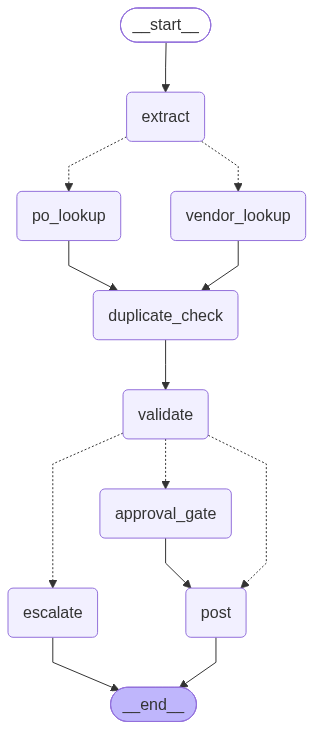

In [39]:
def show_graph(app):
    g = app.get_graph()
    try:
        from IPython.display import Image, display
        display(Image(g.draw_mermaid_png()))
    except Exception:
        print(g.draw_mermaid())


show_graph(build_graph("graph"))

## 4.9 Running and resuming

`run_graph` compiles the graph, invokes it on a thread and reports the outcome. If the run stopped at an `interrupt()`, the returned state has an `__interrupt__` key and the outcome is `paused`.

`resume_graph` is written as if it were **a different process, later**. It shares nothing with `run_graph` except the `thread_id` and the checkpoint store. It gets a fresh `World` and a fresh `Trace`, reads the checkpoint, and continues from the interrupt with `Command(resume=...)`.

In [40]:
def run_graph(model, world: World, invoice_text: str, scenario_key: str, variant: str = "graph",
              thread_id: str | None = None, persist_path: str | None = None) -> Trace:
    trace = world.trace = Trace(variant, scenario_key)
    app = build_graph(variant, persist_path)
    thread_id = thread_id or f"{scenario_key}-{variant}-{uuid.uuid4().hex[:6]}"      # fresh thread per run unless the caller pins one
    config = {"configurable": {"thread_id": thread_id}}
    state = app.invoke({"invoice_text": invoice_text, "log": []}, config=config, context=Ctx(model, world))
    if "__interrupt__" in state:
        trace.note("approval_gate", f"INTERRUPTED: {json.dumps(state['__interrupt__'][0].value)}")
        trace.note("approval_gate", f"resume later with thread_id={thread_id!r}")
        return trace.end("paused", "waiting for human approval")
    return finish(trace, world)


def resume_graph(model, world: World, scenario_key: str, thread_id: str, approved: bool, by: str,
                 variant: str = "graph", persist_path: str | None = None) -> Trace:
    """A different process, later. Same thread_id, same checkpoint store, carry on from the interrupt."""
    trace = world.trace = Trace(variant, scenario_key)
    app = build_graph(variant, persist_path)
    config = {"configurable": {"thread_id": thread_id}}
    snapshot = app.get_state(config)
    if not snapshot.next:
        return trace.end("failed", "no pending interrupt on this thread")
    trace.note("resume", f"resuming at {snapshot.next} from checkpoint {snapshot.config['configurable'].get('checkpoint_id', '')[:8]}")
    if approved:
        app.invoke(Command(resume={"approved": True, "by": by}), config=config, context=Ctx(model, world))
    else:
        # Rejected: end the thread with a ticket. (Exercise 4 moves this inside the graph as a conditional edge.)
        call_tool(world, "escalate_to_human", reason="needs_approval", summary=f"Rejected by {by} at the approval gate.")
    return finish(trace, world)

## 4.10 The same runs, on the graph

**S1, the clean invoice.** The loop took 4 model calls. Count them here. `lookup_vendor` and `lookup_po` run in the same step: the graph fans out after `extract` and joins before `duplicate_check`.

In [41]:
tr, world = run_one("graph", "S1")


== GRAPH  S1  ->  posted  (LDG-00001 approved_by=auto)
  model   extract            in=391   out=128  ```json {"document_type": "invoice", "vendor_name": "Kovai Steel Traders", "gsti
  tool    lookup_po          {"po_number": "PO-7781"}                                               -> {"po_number": "PO-7781", "vendor_id": "V-1001", "amount": 118000.0, "currency": 
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"vendor_id": "V-1001", "name": "Kovai Steel Traders", "gstin": "33AAACK1234F1Z5
  tool    check_duplicate    {"vendor_id": "V-1001", "invoice_number": "KST/2026/0912", "amount": 1 -> {"duplicate": false}
  tool    post_to_ledger     {"amount": 118000.0, "approved_by": "auto", "vendor_id": "V-1001", "in -> {"ledger_id": "LDG-00001", "vendor_id": "V-1001", "invoice_number": "KST/2026/09
  model calls=1  tokens in/out=391/128  tool calls=4  wall=2.79s


**S2, the duplicate.** Same outcome as the loop. The difference is *why*. The loop escalated because the model followed rule 4. The graph escalated because there is no edge to `post` that skips `duplicate_check`. The loop got it right. The graph cannot get it wrong. Which one do you want on the payment run?

In [42]:
tr, world = run_one("graph", "S2")


== GRAPH  S2  ->  escalated  (duplicate)
  model   extract            in=336   out=152  {"document_type": "invoice", "vendor_name": "Sri Balaji Packaging", "gstin": "33
  tool    lookup_po          {"po_number": "PO-7782"}                                               -> {"po_number": "PO-7782", "vendor_id": "V-1002", "amount": 42500.0, "currency": "
  tool    lookup_vendor      {"vendor_name": "Sri Balaji Packaging"}                                -> {"vendor_id": "V-1002", "name": "Sri Balaji Packaging", "gstin": "33AABCS5678G1Z
  tool    check_duplicate    {"vendor_id": "V-1002", "invoice_number": "SBP-4471", "amount": 42500. -> {"duplicate": true, "matched": {"ledger_id": "LDG-00017", "vendor_id": "V-1002",
  tool    escalate_to_human  {"reason": "duplicate", "summary": "Invoice SBP-4471 already posted as -> {"ticket_id": "EXC-0001", "reason": "duplicate", "summary": "Invoice SBP-4471 al
  model calls=1  tokens in/out=336/152  tool calls=4  wall=2.11s


**S5, the flaky service.** The loop paid extra model calls to decide to retry. Here there are three `lookup_vendor` attempts in the trace and still one model call. The retry decision cost zero tokens.

In [43]:
tr, world = run_one("graph", "S5")
print("vendor service calls:", world.vendor_service_calls, "| model calls:", tr.model_calls)


== GRAPH  S5  ->  posted  (LDG-00001 approved_by=auto)
  model   extract            in=285   out=128  ```json {"document_type": "invoice", "vendor_name": "Kovai Steel Traders", "gsti
  tool    lookup_po          {"po_number": "PO-7781"}                                               -> {"po_number": "PO-7781", "vendor_id": "V-1001", "amount": 118000.0, "currency": 
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"error": "vendor-service: 503 Service Unavailable (retry later)", "kind": "tran
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"error": "vendor-service: 503 Service Unavailable (retry later)", "kind": "tran
  tool    lookup_vendor      {"vendor_name": "Kovai Steel Traders"}                                 -> {"vendor_id": "V-1001", "name": "Kovai Steel Traders", "gstin": "33AAACK1234F1Z5
  tool    check_duplicate    {"vendor_id": "V-1001", "invoice_number": "KST/2026

## 4.11 S7: pause today, resume tomorrow

This run uses a checkpointer on disk (SQLite) and a pinned `thread_id`, because the point is surviving a restart.

Run the first cell. The graph extracts, looks up, checks, validates, reaches `approval_gate`, saves its state and **stops**. Nothing is posted.

In [44]:
CHECKPOINTS = "notebook_checkpoints.sqlite"
THREAD = "S7-notebook"

tr, world = run_one("graph", "S7", thread_id=THREAD, persist_path=CHECKPOINTS)
print("\nledger:", world.ledger, "  exceptions:", world.exceptions)


== GRAPH  S7  ->  paused  (waiting for human approval)
  model   extract            in=303   out=131  ```json {"document_type": "invoice", "vendor_name": "Nilgiri Logistics", "gstin"
  tool    lookup_vendor      {"vendor_name": "Nilgiri Logistics"}                                   -> {"vendor_id": "V-1003", "name": "Nilgiri Logistics", "gstin": "33AADCN9012H1Z9",
  tool    lookup_po          {"po_number": "PO-7790"}                                               -> {"po_number": "PO-7790", "vendor_id": "V-1003", "amount": 265000.0, "currency": 
  tool    check_duplicate    {"vendor_id": "V-1003", "invoice_number": "NL-Q3-0091", "amount": 2650 -> {"duplicate": false}
  note    approval_gate      INTERRUPTED: {"question": "Approve this invoice for payment?", "vendor": "Nilgiri Logistics", "invoice_number": "NL-Q3-0091", "amount": 265000.0, "po_number": "PO-7790"}
  note    approval_gate      resume later with thread_id='S7-notebook'
  model calls=1  tokens in/out=303/131  tool calls=3  

Go home. Next morning Vinitha approves it.

The cell below shares **nothing** with the one above except the thread id and the SQLite file: new graph object, new database connection, fresh `World`, fresh `Trace`. To prove it to yourself, restart the kernel, re-run the definition cells (Parts 1 and 2, then 4.1 to 4.9), skip the cell above and run only this one.

Look at the model calls in the summary line. The extraction from yesterday was not repeated. It came out of the checkpoint.

In [45]:
world2 = SCENARIOS["S7"].make_world()      # "next morning": nothing carried over in memory
tr2 = resume_graph(model, world2, "S7", thread_id="S7-notebook", approved=True, by="Vinitha", persist_path="notebook_checkpoints.sqlite")
tr2.print_report()
world2.ledger


== GRAPH  S7  ->  posted  (LDG-00001 approved_by=Vinitha)
  note    resume             resuming at ('approval_gate',) from checkpoint 1f1b42c8
  note    approval_gate      approval received: {'approved': True, 'by': 'Vinitha'}
  tool    post_to_ledger     {"amount": 265000.0, "approved_by": "Vinitha", "vendor_id": "V-1003",  -> {"ledger_id": "LDG-00001", "vendor_id": "V-1003", "invoice_number": "NL-Q3-0091"
  model calls=0  tokens in/out=0/0  tool calls=1  wall=0.02s


[{'ledger_id': 'LDG-00001',
  'vendor_id': 'V-1003',
  'invoice_number': 'NL-Q3-0091',
  'amount': 265000.0,
  'po_number': 'PO-7790',
  'approved_by': 'Vinitha'}]

## 4.12 S6: the branch nobody drew

So far the graph has won every round. Now the credit note. The loop, for the record, handles it:

In [46]:
tr, world = run_one("loop", "S6")


== LOOP  S6  ->  escalated  (other)
  model   turn 1             in=1764  out=212  This is a credit note, not a payable invoice, so I'll escalate it.
  tool    escalate_to_human  {"reason": "other", "summary": "Document received from Sri Balaji Pack -> {"ticket_id": "EXC-0001", "reason": "other", "summary": "Document received from 
  model   turn 2             in=2124  out=55   Escalated (ticket EXC-0001) since this document is a credit note, not a payable 
  model calls=2  tokens in/out=3888/267  tool calls=1  wall=4.93s


And the graph:

In [47]:
tr, world = run_one("graph", "S6")
world.ledger


== GRAPH  S6  ->  posted  (LDG-00001 approved_by=auto)
  model   extract            in=317   out=126  ```json {"document_type": "credit_note", "vendor_name": "Sri Balaji Packaging", 
  tool    lookup_vendor      {"vendor_name": "Sri Balaji Packaging"}                                -> {"vendor_id": "V-1002", "name": "Sri Balaji Packaging", "gstin": "33AABCS5678G1Z
  tool    check_duplicate    {"vendor_id": "V-1002", "invoice_number": "SBP-CN-0093", "amount": -50 -> {"duplicate": false}
  tool    post_to_ledger     {"amount": -5015.0, "approved_by": "auto", "vendor_id": "V-1002", "inv -> {"ledger_id": "LDG-00001", "vendor_id": "V-1002", "invoice_number": "SBP-CN-0093
  model calls=1  tokens in/out=317/126  tool calls=3  wall=2.44s


[{'ledger_id': 'LDG-00001',
  'vendor_id': 'V-1002',
  'invoice_number': 'SBP-CN-0093',
  'amount': -5015.0,
  'po_number': None,
  'approved_by': 'auto'}]

**The graph posted -5,015 to the ledger.** A negative payable, approved by `auto`.

Read the trace from the top. The `extract` node returned `document_type: credit_note`. **The model told you.** Your graph had no edge to hear it. `route_after_extract` never looks at `document_type`, every check downstream passed (known vendor, no PO, not a duplicate, under the threshold), and the only road left led to `post`.

This is the graph's failure mode: it is exactly as smart as the branches you thought of on the day you drew it. The loop has the opposite profile. It reads the document, notices it is odd, and copes.

What the graph costs you is also visible by now: about five times the code (the loop is the prompt plus `run_loop`; the graph is everything from 4.1 to 4.9), a state schema you have to keep honest, and a router that only knows the branches you drew.

---
# Part 5. The hybrid

Do not throw the graph away, and do not go back to the loop. Put a loop **inside a node**.

Anything that is not an invoice goes to a `triage` node, and `triage` is a small loop with four constraints:

| Constraint | In the code |
|---|---|
| **Turn budget** | `for turn in range(1, 5)`. If it runs out, the graph escalates for it. |
| **Fewer tools** | Lookups and `escalate_to_human` only. `post_to_ledger` is not in the list, so this loop *cannot* move money. |
| **Typed exit** | The node returns state the graph can route on, not prose. |
| **One job** | Work out what this document is and who should see it. Nothing else. |

The graph owns the topology. The loop owns judgment inside one node.

In [48]:
# A LOOP INSIDE A NODE. Bounded turns, reduced tool surface, no post_to_ledger.
TRIAGE_TOOLS = [t for t in TOOL_SCHEMAS if t["name"] in {"lookup_vendor", "lookup_po", "escalate_to_human"}]
TRIAGE_PROMPT = ("You are an AP analyst's assistant. This document is NOT a standard payable invoice. "
                 "Work out what it is and what should happen to it (use lookup tools if helpful), then call escalate_to_human "
                 "with the best reason code (duplicate, po_mismatch, unknown_vendor, other) and a summary an analyst can act on. "
                 "You cannot post anything. Be brief.")


def triage(state: APState, runtime: Runtime[Ctx]) -> APState:
    model, world = runtime.context.model, runtime.context.world
    messages = [{"role": "user", "content": f"Extracted fields: {json.dumps(state['fields'])}\n\nDocument:\n{state['invoice_text'].strip()}"}]
    for turn in range(1, 5):                                                     # the budget
        reply = model.complete(TRIAGE_PROMPT, messages, tools=TRIAGE_TOOLS)      # no post_to_ledger in this list
        world.trace.model(f"triage turn {turn}", reply)
        messages.append(reply.as_assistant_message())
        if not reply.tool_calls:
            break
        results = [run_tool(world, tc.name, tc.args) for tc in reply.tool_calls]
        messages.append(tool_results(reply, results))
        if world.exceptions:
            break
    if not world.exceptions:   # out of turns without a decision: the graph escalates for it
        call_tool(world, "escalate_to_human", reason="other", summary="Triage loop exhausted its turn budget without a decision.")
    return {"result": world.exceptions[-1], "log": [f"triage -> {world.exceptions[-1]['ticket_id']}"]}

And the router that was missing. Compare it with `route_after_extract` in 4.7. The whole fix is this `if`.

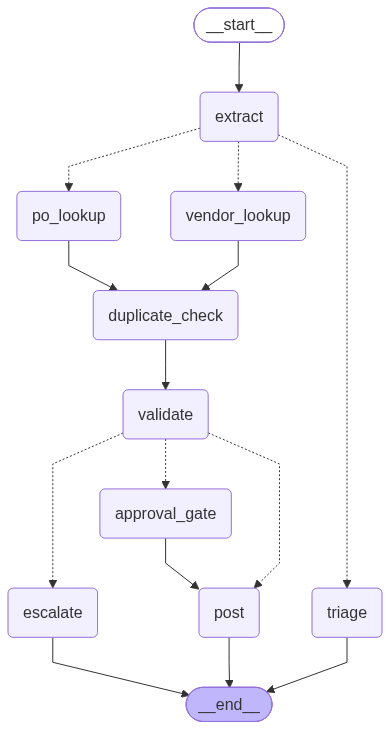

In [49]:
def route_after_extract_hybrid(state: APState) -> list[str] | str:
    if state["fields"].get("document_type") != "invoice":
        return "triage"
    return ["vendor_lookup", "po_lookup"]


show_graph(build_graph("hybrid"))

The credit note again, on the hybrid.

In [50]:
tr, world = run_one("hybrid", "S6")
print("\nledger:", world.ledger)
world.exceptions


== HYBRID  S6  ->  escalated  (other)
  model   extract            in=317   out=126  ```json {"document_type": "credit_note", "vendor_name": "Sri Balaji Packaging", 
  model   triage turn 1      in=1151  out=95   (no text) asks for: lookup_vendor
  tool    lookup_vendor      {"vendor_name": "Sri Balaji Packaging"}                                -> {"vendor_id": "V-1002", "name": "Sri Balaji Packaging", "gstin": "33AABCS5678G1Z
  model   triage turn 2      in=1289  out=322  This is a credit note, not a payable invoice—no matching PO needed for it, but i
  tool    escalate_to_human  {"reason": "other", "summary": "Document is a Credit Note (No. SBP-CN- -> {"ticket_id": "EXC-0001", "reason": "other", "summary": "Document is a Credit No
  model calls=3  tokens in/out=2757/543  tool calls=2  wall=8.0s

ledger: []


[{'ticket_id': 'EXC-0001',
  'reason': 'other',
  'summary': 'Document is a Credit Note (No. SBP-CN-0093, dated 16/09/2026) from Sri Balaji Packaging (vendor V-1002, GSTIN verified, active) for -₹5,015.00 (₹4,250 credit + ₹765 GST reversal), issued against original invoice SBP-4471 (03/09/2026) for 500 damaged boxes returned. Vendor requests adjustment against next payment. Action needed: AP should locate/verify original invoice SBP-4471 in the ledger and apply this credit against the next payment to this vendor rather than posting as a new payable. No PO reference provided.'}]

Escalated, nothing posted, and the ticket says what the document actually is.

An ordinary invoice never enters `triage`, so the hybrid costs nothing extra on the happy path:

In [51]:
tr, world = run_one("hybrid", "S1", verbose=False)


== HYBRID  S1  ->  posted  (LDG-00001 approved_by=auto)
  model calls=1  tokens in/out=391/128  tool calls=4  wall=2.57s


---
# Part 6. The bench

Every invoice through every build, in one table. It is the same table as the bench slide. When a graph run pauses, the bench plays the human: it resumes the thread with an approval, the way 4.11 did. On Claude this cell makes about fifty model calls and takes a minute or two, so start it and talk over it. On the mock it is instant.

In [52]:
from IPython.display import Markdown, display

BENCH_DB = "notebook_checkpoints.sqlite"


def bench_cell(agent: str, key: str) -> str:
    thread = f"bench-{key}-{agent}-{uuid.uuid4().hex[:6]}"
    tr, world = run_one(agent, key, report=False, thread_id=thread, persist_path=BENCH_DB)
    text, calls, tokens = tr.outcome, tr.model_calls, tr.input_tokens + tr.output_tokens
    if tr.outcome == "paused":                                   # a human approves, later, from a fresh World
        world = SCENARIOS[key].make_world()
        tr2 = resume_graph(model, world, key, thread, approved=True, by="Vinitha", variant=agent, persist_path=BENCH_DB)
        text, calls, tokens = f"paused, then {tr2.outcome}", calls + tr2.model_calls, tokens + tr2.input_tokens + tr2.output_tokens
    if world.ledger and world.ledger[-1]["amount"] < 0:
        text += f" {world.ledger[-1]['amount']:,.0f}"
    if tr.outcome != SCENARIOS[key].expected:                    # the two punchlines
        text = f"**{text.upper()}**"
    return f"{text} ({calls} {'call' if calls == 1 else 'calls'}, {tokens:,} tok)"


table = ["| | Invoice | Loop | Graph | Hybrid |", "|---|---|---|---|---|"]
for k in ORDER:
    table.append(f"| {k} | {SCENARIOS[k].title} | " + " | ".join(bench_cell(agent, k) for agent in ("loop", "graph", "hybrid")) + " |")
print(f"model: {model.name}   (token counts are estimates when the model is 'mock')")
display(Markdown("\n".join(table)))

model: claude-sonnet-5   (token counts are estimates when the model is 'mock')


| | Invoice | Loop | Graph | Hybrid |
|---|---|---|---|---|
| S1 | Clean invoice | posted (4 calls, 9,439 tok) | posted (1 call, 519 tok) | posted (1 call, 519 tok) |
| S2 | Duplicate invoice | escalated (4 calls, 9,453 tok) | escalated (1 call, 506 tok) | escalated (1 call, 500 tok) |
| S3 | Unknown vendor | escalated (3 calls, 6,617 tok) | escalated (1 call, 436 tok) | escalated (1 call, 459 tok) |
| S4 | PO amount mismatch | escalated (3 calls, 6,903 tok) | escalated (1 call, 571 tok) | escalated (1 call, 543 tok) |
| S5 | Flaky vendor service | posted (6 calls, 14,069 tok) | posted (1 call, 413 tok) | posted (1 call, 413 tok) |
| S6 | Credit note (the branch nobody drew) | escalated (2 calls, 4,168 tok) | **POSTED -5,015** (1 call, 443 tok) | escalated (3 calls, 3,259 tok) |
| S7 | Big ticket, needs approval | **ESCALATED** (4 calls, 9,305 tok) | paused, then posted (1 call, 432 tok) | paused, then posted (1 call, 432 tok) |

How to read it:

- **Five scenarios agree** on the outcome (S1 to S5). Where they agree, look at the cost columns. The graph does the same job with one model call, and S5 shows what a retry costs in each.
- **Two scenarios split**, and they are the two signals. S7: an irreversible action that needs a human. The loop can only raise a ticket, the graph pauses and later posts with an approver's name. S6: a branch nobody drew. The plain graph posts a negative payable, the loop and the hybrid escalate.
- The two cells in **BOLD CAPITALS** are the two punchlines, not bugs in the notebook. *graph S6* posted a credit note that should have been escalated. *loop S7* escalated an invoice that should have paused for approval, because a loop cannot pause.

---
# Part 7. Self-checks

Every claim made above, as an assertion. They pin the behaviour under the mock model. With a real model the outcomes should hold, but exact call counts can vary, so the cell skips itself.

In [53]:
def self_check():
    # S1 to S5: all three builds agree on the outcome.
    for key in ("S1", "S2", "S3", "S4", "S5"):
        for agent in ("loop", "graph", "hybrid"):
            tr, world = run_one(agent, key, report=False)
            sc = SCENARIOS[key]
            assert tr.outcome == sc.expected, (agent, key, tr.outcome)
            if sc.expected == "escalated":
                assert world.exceptions[-1]["reason"] == sc.expected_reason and not world.ledger
            else:
                assert len(world.ledger) == 1

    # S5: the loop pays tokens for retries, the graph does not.
    loop, _ = run_one("loop", "S5", report=False)
    graph, gworld = run_one("graph", "S5", report=False)
    assert gworld.vendor_service_calls == 3          # two 503s, then success, handled by RetryPolicy
    assert graph.model_calls == 1                    # extraction only
    assert loop.model_calls > graph.model_calls and loop.input_tokens > graph.input_tokens

    # S6: the graph posts the credit note, the hybrid and the loop do not.
    _, gworld = run_one("graph", "S6", report=False)
    assert gworld.ledger and gworld.ledger[0]["amount"] < 0
    for agent in ("hybrid", "loop"):
        _, w = run_one(agent, "S6", report=False)
        assert not w.ledger and w.exceptions[-1]["reason"] == "other"

    # S7: the graph pauses and resumes from disk, the loop can only escalate.
    import tempfile
    with tempfile.TemporaryDirectory() as d:
        db = os.path.join(d, "ckpt.sqlite")
        tr, world = run_one("graph", "S7", report=False, thread_id="t7", persist_path=db)
        assert tr.outcome == "paused" and not world.ledger
        world2 = SCENARIOS["S7"].make_world()
        tr2 = resume_graph(model, world2, "S7", "t7", approved=True, by="Vinitha", persist_path=db)
        assert tr2.outcome == "posted" and world2.ledger[0]["approved_by"] == "Vinitha" and tr2.model_calls == 0
    tr, world = run_one("loop", "S7", report=False)
    assert tr.outcome == "escalated" and world.exceptions[-1]["reason"] == "needs_approval"
    print("all checks passed")


if model.name == "mock":
    self_check()
else:
    print(f"skipped: these checks pin mock-model behaviour and the model is {model.name}")

skipped: these checks pin mock-model behaviour and the model is claude-sonnet-5


---
# Part 8. When does a loop stop being enough?

**Start with the loop.** It is 40 lines, it handles the branch nobody drew, and it is the right answer more often than framework docs suggest. Escalate on signals, not on a feeling.

## The four escalation signals

The deck lists three families of signals: general (sprawl, predictability, specialists), quality and cost (real fan-out, different models per step), and safety. These four are the safety family, the ones that matter when a node can move money.

1. **Parallel work that converges.** Several lookups feed one decision and you need to know when all of them are in. A join is an edge. In a loop it is hope.
2. **A human before the irreversible.** Money, deletion, an email to a customer. Somebody says yes first, and they are not online now. You need interrupt and resume.
3. **Recovery differs by failure.** A 503 retries, an unknown vendor onboards, a mismatch goes to the PO owner. Different exits, decided by a rule, not by reasoning.
4. **Shared state across steps.** Once three steps touch the same fields, you want a schema and a reducer, not a transcript the model has to re-read.

## Five questions to ask first

1. Can you draw the happy path on a whiteboard without a branch you cannot name?
2. Does anything irreversible happen, and does someone need to approve it first?
3. Does anyone have to wait? Minutes, hours, a business day?
4. Do failures need different recoveries, or is "try again, then give up" enough?
5. Do several steps read and write the same state?

Count the yeses. **Zero or one:** write the loop, ship it, instrument it. **Two or more:** graph outside, loop where the judgment is.

**Where to cut first.** Before you commit to a topology, pull the verifier out into its own node with a fresh context. `triage` in Part 5 is the template: a turn budget, fewer tools, a typed exit, one job.

## Exercises

Each one changes a few lines. Predict the result before you run it.

1. **Break the prompt guarantee.** Delete rule 4 from `SYSTEM_PROMPT` and re-run `loop S2`. With the mock nothing changes, because the mock is a rule table. Try it with a real model, a few times. Then ask what you would have to build to make the loop *unable* to post without the check. (Hint: look at `run_tool`.)
2. **A longer outage.** Set `SCENARIOS["S5"].setup["vendor_failures"] = 5` and run S5 on the loop and on the graph. One gives up politely, one raises. Which failure would you rather debug, and which would you rather have in production at 2 a.m.? What edge would you add to the graph?
3. **A third document type.** Write an S8 that is a vendor *statement* (a list of open invoices, no total payable). Run all three builds on it. Does the hybrid need another edge, or does `triage` already cover it?
4. **Draw the reject edge.** `resume_graph` handles a rejection outside the graph. Move it inside: route `approval_gate` to `post` or `escalate` depending on `state["approval"]["approved"]`.
5. **Close the hole properly.** The hybrid fixes S6 with a router check. Add a second, independent defence: make `validate` refuse any `amount <= 0`. Which of the two fixes would have caught a document type you have not thought of yet?
6. **Move a rule.** Set `PO_TOLERANCE = 0.10` and re-run S4 on the graph. The rule moved with one assignment. Now find the other place the 2% lives: rule 3 of `SYSTEM_PROMPT`, as a literal in a sentence. (The mock reads the constant, so it hides this. A real model reads the sentence.) How many places would you have to change in each build, and which of them could a unit test catch?

## Housekeeping

Section 4.11 writes `notebook_checkpoints.sqlite` next to this notebook. Delete it whenever you like.